# Лабораторная 1: классификация цвета автомобиля




In [2]:
import os
from collections import Counter

import torch
from sklearn.metrics import f1_score

from lab1_color_classification import (
    TrainConfig,
    COLOR_INDEX,
    is_image_file,
    DVMCarsColorDataset,
    make_dataloaders,
    build_resnet18_scratch,
    build_pretrained_resnet,
    build_pretrained_mobilenet,
    train_one_epoch,
    evaluate,
 )

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

d:\projects\ITMO\cv\.win-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

In [3]:
import zipfile
with zipfile.ZipFile("Confirmed_fronts.zip") as item:
  item.extractall()

In [4]:
data_root = "Confirmed_fronts/confirmed_fronts"

color_counter = Counter()
for brand in sorted(os.listdir(data_root)):
    brand_dir = os.path.join(data_root, brand)
    if not os.path.isdir(brand_dir):
        continue
    for year in sorted(os.listdir(brand_dir)):
        year_dir = os.path.join(brand_dir, year)
        if not os.path.isdir(year_dir):
            continue
        for fname in os.listdir(year_dir):
            if not is_image_file(fname):
                continue
            parts = fname.split("$$")
            if len(parts) <= COLOR_INDEX:
                continue
            color = parts[COLOR_INDEX]
            color_counter[color] += 1

len(color_counter), list(color_counter.items())[:20]

(23,
 [('Black', 14317),
  ('Grey', 9474),
  ('Multicolour', 196),
  ('White', 9395),
  ('Red', 6095),
  ('Blue', 8483),
  ('Unlisted', 1516),
  ('Yellow', 667),
  ('Silver', 7770),
  ('Turquoise', 26),
  ('Bronze', 329),
  ('Green', 777),
  ('Beige', 600),
  ('Purple', 362),
  ('Brown', 911),
  ('Orange', 559),
  ('Pink', 87),
  ('Maroon', 26),
  ('Navy', 1),
  ('Gold', 217)])

In [5]:
cfg = TrainConfig(
    data_root=data_root,
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    val_size=0.2,
    random_state=42,
    num_workers=4,
    min_samples_per_class=1000,
)
cfg

TrainConfig(data_root='Confirmed_fronts/confirmed_fronts', batch_size=64, epochs=10, lr=0.001, weight_decay=0.0001, num_workers=4, val_size=0.2, random_state=42, device='cpu', min_samples_per_class=1000, label_smoothing=0.0)

In [6]:
train_loader, val_loader, idx_to_color = make_dataloaders(cfg)
num_classes = len(idx_to_color)
num_classes, list(idx_to_color.values())[:10]

(7, ['Black', 'Grey', 'White', 'Red', 'Blue', 'Unlisted', 'Silver'])

## Обучение моделей

In [15]:
results = {}

### 1 ResNet18 (обучение с нуля)

In [16]:
model = build_resnet18_scratch(num_classes, device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_f1, best_acc = 0.0, 0.0
for epoch in range(cfg.epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    acc, f1_macro = evaluate(model, val_loader, device)
    best_f1 = max(best_f1, f1_macro)
    best_acc = max(best_acc, acc)
    print(f"[ResNet18_scratch] Epoch {epoch+1}/{cfg.epochs} - loss={train_loss:.4f}, acc={acc:.4f}, f1={f1_macro:.4f}")

results["ResNet18_scratch"] = (best_acc, best_f1)
best_acc, best_f1

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

[ResNet18_scratch] Epoch 1/10 - loss=1.0639, acc=0.5082, f1=0.4952


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

...

[ResNet18_scratch] Epoch 9/10 - loss=0.5452, acc=0.8631, f1=0.7955


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

[ResNet18_scratch] Epoch 10/10 - loss=0.5089, acc=0.8505, f1=0.7859


(0.863102541630149, 0.7955179171585255)

In [ ]:
torch.save(model.state_dict(), "resnet18_scratch.pth")
print("ResNet18 (scratch) saved as resnet18_scratch.pth")

ResNet18 (scratch) saved as resnet18_scratch.pth


### 2 ResNet18 (предобученная)

In [18]:
model = build_pretrained_resnet(num_classes, device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_f1, best_acc = 0.0, 0.0
for epoch in range(cfg.epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    acc, f1_macro = evaluate(model, val_loader, device)
    best_f1 = max(best_f1, f1_macro)
    best_acc = max(best_acc, acc)
    print(f"[ResNet18_pretrained] Epoch {epoch+1}/{cfg.epochs} - loss={train_loss:.4f}, acc={acc:.4f}, f1={f1_macro:.4f}")

results["ResNet18_pretrained"] = (best_acc, best_f1)
best_acc, best_f1

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[ResNet18_pretrained] Epoch 1/10 - loss=0.7853, acc=0.7029, f1=0.6844


...

[ResNet18_pretrained] Epoch 9/10 - loss=0.2976, acc=0.8418, f1=0.7831


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

[ResNet18_pretrained] Epoch 10/10 - loss=0.2641, acc=0.8662, f1=0.8051


(0.8785276073619632, 0.8051297681461845)

In [ ]:
torch.save(model.state_dict(), "resnet18_pretrained.pth")
print("ResNet18 (pretrained) saved as resnet18_pretrained.pth")

ResNet18 (pretrained) saved as resnet18_pretrained.pth


### 3 MobileNetV2 (предобученная)

In [20]:
cfg.batch_size = 32
model = build_pretrained_mobilenet(num_classes, device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_f1, best_acc = 0.0, 0.0
for epoch in range(cfg.epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    acc, f1_macro = evaluate(model, val_loader, device)
    best_f1 = max(best_f1, f1_macro)
    best_acc = max(best_acc, acc)
    print(f"[MobileNetV2_pretrained] Epoch {epoch+1}/{cfg.epochs} - loss={train_loss:.4f}, acc={acc:.4f}, f1={f1_macro:.4f}")

results["MobileNetV2_pretrained"] = (best_acc, best_f1)
best_acc, best_f1

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20>
^Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive(): 
              ^  ^ ^^^^^^^^^^^^^^^^^^^
^  

[MobileNetV2_pretrained] Epoch 1/10 - loss=0.7702, acc=0.7426, f1=0.7076


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batches:   0%|          | 0/714 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c51429faa20> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^ ^ ^^ ^ ^^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^^   ^^ ^
   File "/usr/l

[MobileNetV2_pretrained] Epoch 10/10 - loss=0.3497, acc=0.8823, f1=0.8145


(0.882296231375986, 0.8144850549957091)

In [ ]:
torch.save(model.state_dict(), "mobilenetv2_pretrained.pth")
print("MobileNetV2 (pretrained) saved as mobilenetv2_pretrained.pth")

In [7]:
results = {
    "ResNet18_scratch": (0.863102541630149, 0.7955179171585255),
    "ResNet18_pretrained": (0.8785276073619632, 0.8051297681461845),
    "MobileNetV2_pretrained": (0.882296231375986, 0.8144850549957091),
}

best_name, (best_acc, best_f1) = max(results.items(), key=lambda kv: kv[1][1])
print(f"Лучшая модель по F1_macro: {best_name}, F1_macro={best_f1:.4f}, Acc={best_acc:.4f}")

Лучшая модель по F1_macro: MobileNetV2_pretrained, F1_macro=0.8145, Acc=0.8823


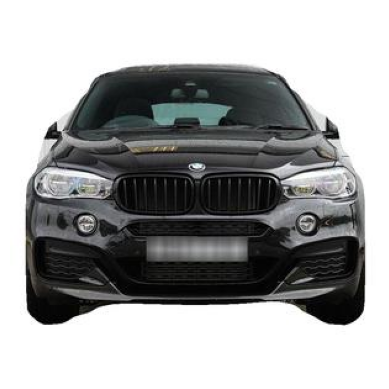

Image: BMW$$X6$$2017$$Black$$8_41$$460$$image_9.jpg
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\gozeb/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 30.7MB/s]


ResNet18 Pretrained prediction: Black
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\gozeb/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 15.7MB/s]


MobileNetV2 Pretrained prediction: Black
ResNet18 Scratch prediction: Black
----------------------------------------


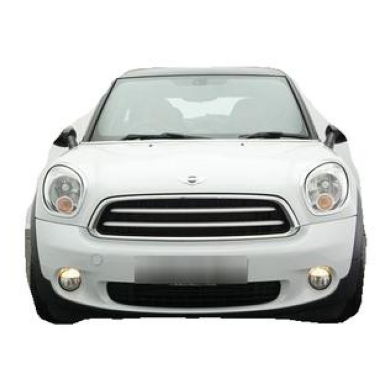

Image: MINI$$Paceman$$2013$$White$$54_7$$90$$image_6.jpg
ResNet18 Pretrained prediction: Grey
MobileNetV2 Pretrained prediction: Grey
ResNet18 Scratch prediction: Grey
----------------------------------------


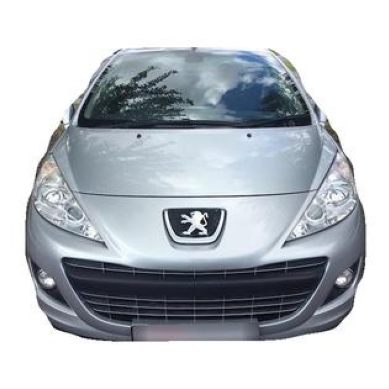

Image: Peugeot$$207 CC$$2011$$Silver$$69_10$$25$$image_0.jpg
ResNet18 Pretrained prediction: Silver
MobileNetV2 Pretrained prediction: Silver
ResNet18 Scratch prediction: Silver
----------------------------------------


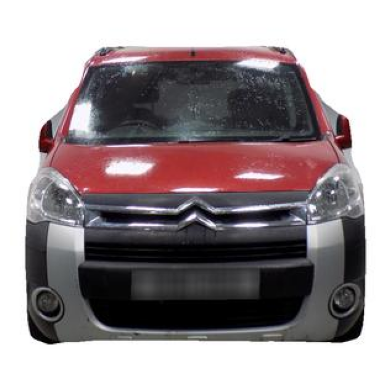

Image: Citroen$$Berlingo$$2010$$Red$$18_2$$158$$image_6.jpg
ResNet18 Pretrained prediction: Red
MobileNetV2 Pretrained prediction: Red
ResNet18 Scratch prediction: Red
----------------------------------------


In [8]:
import torch
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

resnet18_pretrained_path = 'resnet18_pretrained.pth'
mobilenetv2_pretrained_path = 'mobilenetv2_pretrained.pth'
resnet18_scratch_path = 'resnet18_scratch.pth'

example_img_paths = [
    'Confirmed_fronts/confirmed_fronts/BMW/2017/BMW$$X6$$2017$$Black$$8_41$$460$$image_9.jpg',
    'Confirmed_fronts/confirmed_fronts/MINI/2013/MINI$$Paceman$$2013$$White$$54_7$$90$$image_6.jpg',
    'Confirmed_fronts/confirmed_fronts/Peugeot/2011/Peugeot$$207 CC$$2011$$Silver$$69_10$$25$$image_0.jpg',
    'Confirmed_fronts/confirmed_fronts/Citroen/2010/Citroen$$Berlingo$$2010$$Red$$18_2$$158$$image_6.jpg',
]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def load_image(img_path):
    img = Image.open(img_path).convert('RGB')
    return transform(img).unsqueeze(0)

def show_image(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

def infer_model(model_path, model_builder, num_classes, img_tensor):
    model = model_builder(num_classes, 'cpu')
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)
    return pred.item()

from lab1_color_classification import build_pretrained_resnet, build_pretrained_mobilenet, build_resnet18_scratch

for img_path in example_img_paths:
    img_tensor = load_image(img_path)
    show_image(img_path)
    print(f'Image: {os.path.basename(img_path)}')
    for name, path, builder in [
        ('ResNet18 Pretrained', resnet18_pretrained_path, build_pretrained_resnet),
        ('MobileNetV2 Pretrained', mobilenetv2_pretrained_path, build_pretrained_mobilenet),
        ('ResNet18 Scratch', resnet18_scratch_path, build_resnet18_scratch),
    ]:
        pred_idx = infer_model(path, builder, len(idx_to_color), img_tensor)
        print(f'{name} prediction: {idx_to_color.get(pred_idx, pred_idx)}')
    print('-' * 40)